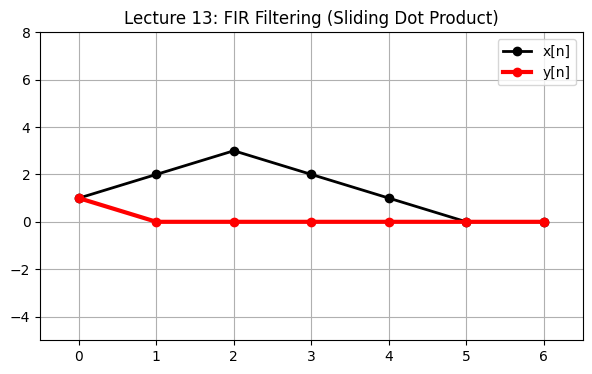

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 13: FIR Filtering Animation
# Same style as Lecture 9
# -----------------------------

# Input signal
x = np.array([1, 2, 3, 2, 1, 0, 0])
N = len(x)

# FIR filter coefficients (impulse response)
b = np.array([1, -1, 2])
M = len(b)

# FIR output (linear convolution, causal)
y = np.zeros(N)
for n in range(N):
    for k in range(M):
        if n - k >= 0:
            y[n] += b[k] * x[n - k]

# Setup plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(-0.5, N - 0.5)
ax.set_ylim(-5, 8)
ax.grid(True)
ax.set_title("Lecture 13: FIR Filtering (Sliding Dot Product)")

n = np.arange(N)

# Plot input signal
ax.plot(n, x, 'ko-', lw=2, label="x[n]")

# Animated output signal
y_line, = ax.plot([], [], 'ro-', lw=3, label="y[n]")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture 9 style)
# -----------------------------
def update(frame):
    y_display = np.zeros(N)
    y_display[:frame+1] = y[:frame+1]

    y_line.set_data(n, y_display)
    return (y_line,)

anim = FuncAnimation(fig, update, frames=N, interval=700)

HTML(anim.to_jshtml())